In [63]:
import json
import torch
import joblib
import pandas as pd
import numpy as np
from pathlib import Path
from typing import Union
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from credit_risk.features import FEATURES_DIR, load_features
from credit_risk.evaluation import evaluate_model
from credit_risk.utils import to_jsonable
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import average_precision_score

In [3]:
feature_splits = load_features()

2026-06-21 16:38:14.405 | INFO     | credit_risk.features:load_features:263 - Loading the processed features...
2026-06-21 16:38:14.755 | INFO     | credit_risk.features:load_features:270 - Loaded successfully!


In [4]:
X_train = feature_splits['train'][0].to_numpy()
y_train = feature_splits['train'][1].to_numpy().ravel()
X_val = feature_splits['val'][0].to_numpy()
y_val = feature_splits['val'][1].to_numpy().ravel()
X_test = feature_splits['test'][0].to_numpy()
y_test = feature_splits['test'][1].to_numpy().ravel()

In [46]:
class MLP(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: list[int] = [128, 64], dropout: float = 0.2):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h in hidden_dim:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_dim = h
            
        layers.append(nn.Linear(prev_dim, 1))
        self.net = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.net(x).squeeze(-1)

In [47]:
def train_one_fold(X_train: np.array, y_train: np.array, X_val: np.array, n_epochs: int = 20, batch_size: int = 2048):
    """Train the MLP for one fold"""
    
    X_train_t = torch.from_numpy(X_train.astype(np.float32))
    y_train_t = torch.from_numpy(y_train.astype(np.float32))
    X_val_t = torch.from_numpy(X_val.astype(np.float32))
    
    model = MLP(input_dim=X_train.shape[1])
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.BCEWithLogitsLoss()
    
    dataset = TensorDataset(X_train_t, y_train_t)
    loader = DataLoader(dataset=dataset, batch_size=batch_size, shuffle=True)
    
    for epoch in range(n_epochs):
        model.train()
        epoch_loss = 0
        
        for xb, yb in loader:
            optimizer.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        # print(f"Epoch {epoch}: loss={epoch_loss/len(loader):.4f}")
        
    # predict
    model.eval()
    with torch.no_grad():
        val_logits = model(X_val_t)
        val_proba = torch.sigmoid(val_logits).numpy()
        
    return val_proba

In [48]:
tscv = TimeSeriesSplit()

In [49]:
# CV
scores = []
i = 1
for train_idx, val_idx in tscv.split(X_train):
    val_proba = train_one_fold(
        X_train=X_train[train_idx],
        y_train=y_train[train_idx],
        X_val=X_train[val_idx],
        n_epochs=30
    )
    score = average_precision_score(y_train[val_idx], val_proba)
    scores.append(score)
    print(f"{i}th fold done...")
    i+=1
    
print("Mean PR-AUC:", np.mean(scores))

1th fold done...
2th fold done...
3th fold done...
4th fold done...
5th fold done...
Mean PR-AUC: 0.2984296665004885


In [50]:
scores

[0.24959622966498446,
 0.2792979912822564,
 0.2997391939156833,
 0.3311998015621759,
 0.33231511607734276]

In [51]:
def train_nn(X_train: np.array, y_train: np.array, n_epochs: int = 20, dropout: float = 0.2, batch_size: int = 2048, hidden_dim: list[int] = [126, 64]) -> Union[MLP, list[float]]:
    """trains the MLP model"""
    X_train_t = torch.from_numpy(X_train.astype(np.float32))
    y_train_t = torch.from_numpy(y_train.astype(np.float32))
    
    model = MLP(input_dim=X_train.shape[1], hidden_dim=hidden_dim, dropout=dropout)
    cost_fn = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    
    dataset = TensorDataset(X_train_t, y_train_t)
    loader = DataLoader(dataset=dataset, batch_size=batch_size, shuffle=True)
    
    loss_track = []
    for epoch in range(n_epochs):
        epoch_cost = 0
        
        for xb, yb in loader:
            optimizer.zero_grad()
            
            # forward
            logits = model(xb)
            loss = cost_fn(logits, yb)
            
            # backward
            loss.backward()
            optimizer.step()
            epoch_cost += loss.item()
            
        loss_track.append(epoch_cost/len(loader))
        print(f"{epoch+1} epoch: avg loss per batch - {epoch_cost/len(loader)}")
        
    return model, loss_track

In [93]:
train_nn_model, loss_track = train_nn(
    X_train=X_train,
    y_train=y_train,
    n_epochs=25
)

1 epoch: avg loss per batch - 0.43685604435832875
2 epoch: avg loss per batch - 0.41889295517875436
3 epoch: avg loss per batch - 0.4172153564398749
4 epoch: avg loss per batch - 0.4157095343658799
5 epoch: avg loss per batch - 0.41496593622784866
6 epoch: avg loss per batch - 0.41401635084235877
7 epoch: avg loss per batch - 0.4135842252718775
8 epoch: avg loss per batch - 0.41301788768747394
9 epoch: avg loss per batch - 0.4124301966083677
10 epoch: avg loss per batch - 0.4121472930960488
11 epoch: avg loss per batch - 0.4115712854423021
12 epoch: avg loss per batch - 0.4111392664020522
13 epoch: avg loss per batch - 0.41095456402552755
14 epoch: avg loss per batch - 0.41054242352644604
15 epoch: avg loss per batch - 0.4101053294644021
16 epoch: avg loss per batch - 0.40994679143554286
17 epoch: avg loss per batch - 0.40956389119750575
18 epoch: avg loss per batch - 0.40923057457334117
19 epoch: avg loss per batch - 0.40884552242463096
20 epoch: avg loss per batch - 0.408526870765184

In [94]:
X_train_t = torch.from_numpy(X_train.astype(np.float32))
X_val_t = torch.from_numpy(X_val.astype(np.float32))
X_test_t = torch.from_numpy(X_test.astype(np.float32))

In [95]:
train_nn_model.eval()
with torch.no_grad():
    train_proba = torch.sigmoid(train_nn_model(X_train_t)).numpy()
    val_proba = torch.sigmoid(train_nn_model(X_val_t)).numpy()
    test_proba = torch.sigmoid(train_nn_model(X_test_t)).numpy()

In [96]:
nn_eval_dict = evaluate_model(
    y_train=y_train,
    train_proba=train_proba,
    y_val=y_val,
    val_proba=val_proba,
    y_test=y_test,
    test_proba=test_proba,
    fn_cost=10000,
    fp_cost=2000
)

In [97]:
nn_eval_dict

{'threshold': np.float64(0.14),
 'train': {'ROC-AUC': 0.7277986069218731,
  'PR-AUC': 0.3562815890568383,
  'brier_score': 0.12511122226715088,
  'precision': 0.25726615328454466,
  'recall': 0.7629228687415426,
  'confusion_matrix': array([[217538, 170909],
         [ 18396,  59199]])},
 'val': {'ROC-AUC': 0.7064688411116442,
  'PR-AUC': 0.3436229864036478,
  'brier_score': 0.13781626522541046,
  'precision': 0.270068488347631,
  'recall': 0.748661923460726,
  'confusion_matrix': array([[186905, 156136],
         [ 19394,  57769]])},
 'test': {'ROC-AUC': 0.6926479544602352,
  'PR-AUC': 0.3062166558805486,
  'brier_score': 0.13092032074928284,
  'precision': 0.24838236355326773,
  'recall': 0.7092227808456276,
  'confusion_matrix': array([[202679, 156235],
         [ 21168,  51630]])}}

In [62]:
cwd = Path.cwd()
project_root = cwd.parent
xgb_path = project_root / 'models' / 'tuned_xgb'

In [64]:
with open(xgb_path / 'metric.json', 'r') as f:
    xgb_eval_dict = json.load(f)

In [65]:
xgb_eval_dict

{'threshold': 0.16,
 'train': {'ROC-AUC': 0.7439300157154369,
  'PR-AUC': 0.381689819454631,
  'brier_score': 0.12316741794347763,
  'precision': 0.2783728747025197,
  'recall': 0.7311166956633803,
  'confusion_matrix': [[241383, 147064], [20864, 56731]]},
 'val': {'ROC-AUC': 0.708335490425068,
  'PR-AUC': 0.34885062650079623,
  'brier_score': 0.13714288175106049,
  'precision': 0.2789071369106183,
  'recall': 0.7163796119902025,
  'confusion_matrix': [[200124, 142917], [21885, 55278]]},
 'test': {'ROC-AUC': 0.6935841329758616,
  'PR-AUC': 0.3104578352376564,
  'brier_score': 0.13049693405628204,
  'precision': 0.2591251104930686,
  'recall': 0.6604027583175361,
  'confusion_matrix': [[221458, 137456], [24722, 48076]]}}

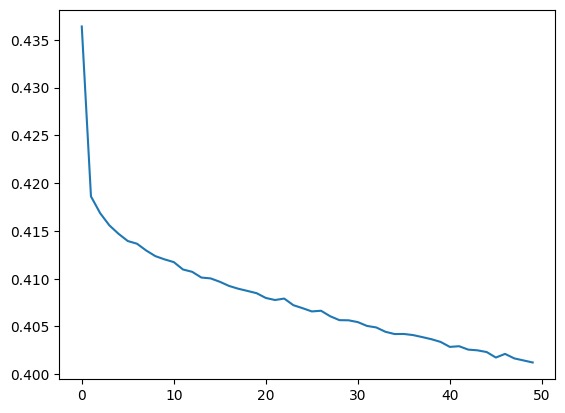

In [73]:
import matplotlib.pyplot as plt

plt.plot(loss_track)

In [79]:
nn_path = project_root / "models" / 'mlp'
nn_path.mkdir(parents=True, exist_ok=True)
torch.save(train_nn_model.state_dict(), nn_path / "model_state.pt")

In [80]:
arch = {
    "input_dim": X_train.shape[1],
    "hidden_dim": [128, 64],
    "dropout": 0.2,
    "batch_size": 2048
}

In [81]:
with open(nn_path / "architecture.json", "w") as f:
    json.dump(arch, f, indent=2)

In [82]:
training_info = {
    "n_epochs": 30,
    "batch_size": 2048,
    "learning_rate": 1e-3,
    "optimizer": "Adam",
    "loss": "BCEWithLogitsLoss",
    "cv_mean_pr_auc": 0.298,
    "framework": "pytorch",
    "framework_version": torch.__version__,
}

with open(nn_path / "training_info.json", "w") as f:
    json.dump(training_info, f, indent=2)

In [84]:
with open(nn_path / "metrics.json", "w") as f:
    json.dump(to_jsonable(nn_eval_dict), f, indent=2)

In [85]:
with open(nn_path / "threshold.json", "w") as f:
    json.dump({"threshold": 0.15, "fn_cost": 10000, "fp_cost": 2000}, f, indent=2)

In [86]:
training_info["preprocessor_path"] = "data/processed/features/preprocessor.pkl"

In [87]:
with open(nn_path / "training_info.json", "w") as f:
    json.dump(training_info, f, indent=2)